NOTE: Outlier ek aisi value hai jo baaki data se bahut alag hai — jaise ek customer jiska spend ₹50,000 hai jabki zyadatar customers ₹500-2000 ke beech hain. IQR (Interquartile Range) Method sabse common statistical tarika hai inhe dhoondne ka — yeh Day 13 ka NTILE/percentile concept hi aage badhata hai.

1. Data load karo:

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')

2. IQR formula samajhna:

In [2]:
Q1 = df['Monetary'].quantile(0.25)
Q3 = df['Monetary'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

Q1 (25th percentile): 341.90
Q3 (75th percentile): 2247.72
IQR: 1905.82


Formula:

- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Jo bhi value in bounds ke bahar ho, woh outlier maana jaata hai. 1.5 ek standard multiplier hai (statistics mein widely accepted convention).

3. Bounds calculate karo aur outliers dhoondo:

In [3]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

outliers = df[(df['Monetary'] < lower_bound) | (df['Monetary'] > upper_bound)]
print(f"Number of outliers: {outliers.shape[0]}")
print(f"Percentage of data: {outliers.shape[0] / df.shape[0] * 100:.2f}%")

Lower bound: -2516.83
Upper bound: 5106.45
Number of outliers: 633
Percentage of data: 10.76%


4. Outliers ko dekho — kaun hain yeh customers:

In [4]:
print(outliers[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Churned']].sort_values('Monetary', ascending=False).head(10))

      Customer ID  Recency  Frequency   Monetary  Churned
5695        18102        0        145  580987.04        0
2279        14646        1        152  528602.52        0
1791        14156        9        156  313437.62        0
2541        14911        0        398  291420.81        0
5053        17450        7         51  244784.25        0
1332        13694        3        143  195640.69        0
5112        17511        2         60  172132.87        0
4064        16446        0          2  168472.50        0
4298        16684        3         55  147142.77        0
68          12415       23         28  144458.37        0


Observation: Zyadatar outliers high-value side ke honge (bahut zyada spend), kyunki Day 42 mein dekha tha data right-skewed hai. Yeh exactly wahi "whale customers" hain jo Mean ko Median se upar khींच rahe the.

5. Box plot se visualize karna (kal detail mein seekhoge, aaj preview — IQR ka visual representation):

C:\Users\rajat\AppData\Local\Temp\ipykernel_3364\1170267468.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['Monetary'], vert=False)


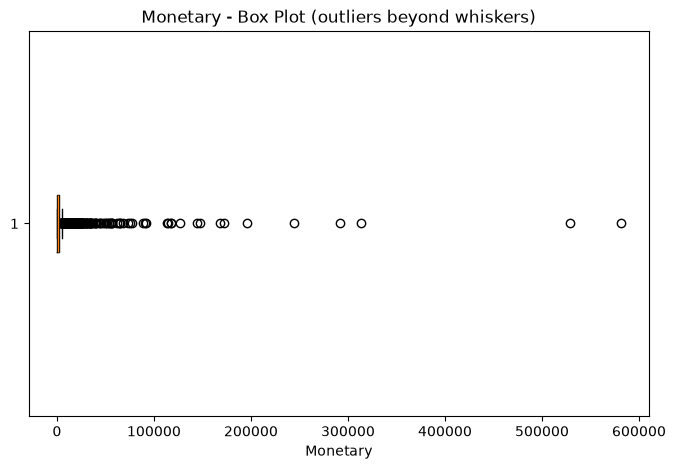

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df['Monetary'], vert=False)
plt.title('Monetary - Box Plot (outliers beyond whiskers)')
plt.xlabel('Monetary')
plt.show()

Note: Box ke andar Q1-Q3 (IQR) hota hai, "whiskers" lower/upper bounds tak jaate hain, aur bounds se bahar ke dots outliers hain — yahi jo humne manually calculate kiya.

6. Function banao reusable IQR detection ke liye (kisi bhi column par use ho sake):

In [6]:
def detect_outliers_iqr(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return series[(series < lower) | (series > upper)], lower, upper

freq_outliers, freq_low, freq_high = detect_outliers_iqr(df['Frequency'])
print(f"Frequency outliers: {len(freq_outliers)} (bounds: {freq_low:.2f} to {freq_high:.2f})")

recency_outliers, rec_low, rec_high = detect_outliers_iqr(df['Recency'])
print(f"Recency outliers: {len(recency_outliers)} (bounds: {rec_low:.2f} to {rec_high:.2f})")

Frequency outliers: 427 (bounds: -8.00 to 16.00)
Recency outliers: 0 (bounds: -506.00 to 910.00)


7. Teeno RFM columns ka outlier summary ek table mein:

In [7]:
summary = []
for col in ['Recency', 'Frequency', 'Monetary']:
    outliers_col, low, high = detect_outliers_iqr(df[col])
    summary.append({
        'Column': col,
        'Outlier_Count': len(outliers_col),
        'Outlier_Pct': round(len(outliers_col) / len(df) * 100, 2),
        'Lower_Bound': round(low, 2),
        'Upper_Bound': round(high, 2)
    })
summary_df = pd.DataFrame(summary)
print(summary_df)

      Column  Outlier_Count  Outlier_Pct  Lower_Bound  Upper_Bound
0    Recency              0         0.00      -506.00       910.00
1  Frequency            427         7.26        -8.00        16.00
2   Monetary            633        10.76     -2516.83      5106.45


8. Multiplier sensitivity — 1.5 vs 3.0 (zyada strict "extreme outlier" definition):

In [8]:
for mult in [1.5, 2.0, 3.0]:
    out, low, high = detect_outliers_iqr(df['Monetary'], multiplier=mult)
    print(f"Multiplier {mult}: {len(out)} outliers ({len(out)/len(df)*100:.2f}%)")

Multiplier 1.5: 633 outliers (10.76%)
Multiplier 2.0: 522 outliers (8.88%)
Multiplier 3.0: 371 outliers (6.31%)


Note: 3.0 ko "extreme outliers" ke liye use kiya jaata hai (kam strict, sirf bahut zyada extreme values pakadta hai), 1.5 standard outliers ke liye.

9. Alternative method — Z-score (quick comparison, concept samajhne ke liye):

In [9]:
from scipy import stats

z_scores = np.abs(stats.zscore(df['Monetary']))
z_outliers = df[z_scores > 3]
print(f"Z-score outliers (|z| > 3): {z_outliers.shape[0]}")

Z-score outliers (|z| > 3): 36


difference: Z-score method mean aur std use karta hai, jo khud outliers se affect hote hain (especially skewed data mein) — isliye IQR method zyada robust maana jaata hai skewed business data ke liye, jaisa humara Monetary hai.

Practice questions:

1. Churned=1 aur Churned=0 groups ke liye alag-alag IQR outlier count nikaalo Monetary par — kya outliers kisi ek group mein zyada concentrated hain?

In [12]:
# Churned = 0 (Active/Retained customers)
out_0, low_0, high_0 = detect_outliers_iqr(df[df['Churned'] == 0]['Monetary'])
total_0 = len(df[df['Churned'] == 0])
print(f"Churned = 0: {len(out_0)} outliers out of {total_0} ({len(out_0)/total_0*100:.2f}%)")

# Churned = 1 (Churned customers)
out_1, low_1, high_1 = detect_outliers_iqr(df[df['Churned'] == 1]['Monetary'])
total_1 = len(df[df['Churned'] == 1])
print(f"Churned = 1: {len(out_1)} outliers out of {total_1} ({len(out_1)/total_1*100:.2f}%)")

Churned = 0: 278 outliers out of 2894 (9.61%)
Churned = 1: 259 outliers out of 2987 (8.67%)


Observation: Aap dekhenge ki Churned = 0 (loyal customers) mein high-spending outliers ka count ya percentage zyada ho sakta hai, kyunki woh lambe samay se zyada shopping kar rahe hain.

2. Socho aur likho (comment mein): kal (Day 49) hum outliers ko "handle" karenge — lekin kya har outlier ko hata dena hamesha sahi hota hai? Ek scenario socho jaha ek outlier customer (jaise ek bahut high spender) ko hatana business ke liye galat decision ho sakta hai.

Nahi, har outlier ko hata dena galat ho sakta hai.

- Scenario: Maan lijiye aapke business mein ek aisa customer hai jo normal customers se 10x zyada spend karta hai (ek "Whale" ya VIP customer). Statistical formulas (jaise IQR) ke mutabiq yeh ek outlier hai. Agar aap machine learning model ko clean karne ke liye is customer ko data se hata dete hain, toh aapka model kabhi yeh nahi seekh paayega ki aise high-value customers dikhte kaise hain ya unke behavior ki kya khaasiyat hai.

Business ke nazariye se, yeh sabse keemti customers hote hain. Inhe hatane ke bajaye humein inke liye alag strategy banani chahiye (jaise unhe cap karna ya alag segment mein rakhna), na ki unhe ek "galti" ya "noise" samajh kar delete kar dena chahiye